# Task 4 — Synthetic Likelihood MCMC

**Reference:** Wood (2010), *Statistical inference for noisy nonlinear ecological dynamic systems*.

## Idea

Instead of comparing summary statistics through a distance function, **assume** the summaries
$s(y)$ follow a multivariate normal distribution conditional on the parameters:
$$p_\text{SL}(s_\text{obs} \mid \theta) \approx \mathcal{N}\!\left(s_\text{obs};\; \mu(\theta),\; \Sigma(\theta)\right)$$
The mean $\mu(\theta)$ and covariance $\Sigma(\theta)$ are **estimated from $N_\text{sim}$ simulations** at the proposed $\theta$.  
This defines an approximate likelihood that can be plugged directly into **Metropolis–Hastings MCMC**.

### Practical setup for this problem
The observed data consists of $R = 40$ independent replicates at the same unknown $\theta^*$.  
We treat a single "dataset" as $R$ replicates and define:
$$s_\text{obs} = \frac{1}{R}\sum_{r=1}^{R} s(y_r^\text{obs})$$
Each SL evaluation simulates $N_\text{sim}$ datasets of $R$ replicates and fits a Gaussian to the distribution of $\bar{s}$.

**Runtime estimate** (defaults $N_\text{sim}=50$, $R=40$): ~$0.12$ s/step → 2 000 steps ≈ **4 min**.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

from simulator import simulate_batch

## 1. Load Data

In [2]:
import pandas as pd

def load_observed(data_dir):
    inf_df = pd.read_csv(data_dir / "infected_timeseries.csv")
    rew_df = pd.read_csv(data_dir / "rewiring_timeseries.csv")
    deg_df = pd.read_csv(data_dir / "final_degree_histograms.csv")
    obs_inf = inf_df.pivot(index="replicate_id", columns="time",   values="infected_fraction").sort_index().values.astype(float)
    obs_rew = rew_df.pivot(index="replicate_id", columns="time",   values="rewire_count").sort_index().values.astype(float)
    obs_deg = deg_df.pivot(index="replicate_id", columns="degree", values="count").sort_index().values.astype(float)
    return obs_inf, obs_rew, obs_deg

obs_inf, obs_rew, obs_deg = load_observed(ROOT / "data")

PRIOR_LOW   = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH  = np.array([0.50, 0.20, 0.8])
PARAM_NAMES = [r"$\beta$", r"$\gamma$", r"$\rho$"]
R_OBS       = obs_inf.shape[0]   # 40 observed replicates
print(f"Observed: inf={obs_inf.shape}, rew={obs_rew.shape}, deg={obs_deg.shape}")

Observed: inf=(40, 201), rew=(40, 201), deg=(40, 31)


## 2. Summary Statistics

**Important:** `N_sim` simulations are used to estimate a $p \times p$ covariance matrix,  
so you need $N_\text{sim} \gg p$ (number of features). Use scalar summary sets for this reason.  
Change `ACTIVE_SET` to experiment — keep $N_\text{sim} > 3 \times p$ as a rule of thumb.

In [3]:
DEGREES = np.arange(31, dtype=float)

def _degree_mean(deg):
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    return ((deg * DEGREES).sum(axis=2, keepdims=True) / total).mean(axis=1)

def _degree_std(deg):
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    mu  = (deg * DEGREES).sum(axis=2) / total.squeeze(2)
    mu2 = (deg * DEGREES**2).sum(axis=2) / total.squeeze(2)
    return np.sqrt((mu2 - mu**2).clip(min=0)).mean(axis=1, keepdims=True)

FEATURE_FUNCS = {
    "peak_inf":         lambda i, w, d: np.max(i, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_inf": lambda i, w, d: np.argmax(i, axis=2).astype(float).mean(axis=1, keepdims=True),
    "final_inf":        lambda i, w, d: i[:, :, -1].mean(axis=1, keepdims=True),
    "total_inf":        lambda i, w, d: i.sum(axis=2).mean(axis=1, keepdims=True),
    "std_peak_inf":     lambda i, w, d: np.max(i, axis=2).std(axis=1, keepdims=True),
    "total_rew":        lambda i, w, d: w.sum(axis=2).mean(axis=1, keepdims=True),
    "peak_rew":         lambda i, w, d: np.max(w, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_rew": lambda i, w, d: np.argmax(w, axis=2).astype(float).mean(axis=1, keepdims=True),
    "mean_degree":      lambda i, w, d: _degree_mean(d),
    "std_degree":       lambda i, w, d: _degree_std(d),
    "isolated_frac":    lambda i, w, d: (d[:, :, 0] / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
    "high_degree_frac": lambda i, w, d: (d[:, :, 20:].sum(axis=2) / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
}

SUMMARY_SETS = {
    "infection_only": ["peak_inf", "time_to_peak_inf", "final_inf", "total_inf"],            # p=4
    "no_degree":      ["peak_inf", "time_to_peak_inf", "final_inf", "total_inf",
                       "std_peak_inf", "total_rew", "peak_rew", "time_to_peak_rew"],           # p=8
    "all_scalar":     ["peak_inf", "time_to_peak_inf", "final_inf", "total_inf", "std_peak_inf",
                       "total_rew", "peak_rew", "time_to_peak_rew",
                       "mean_degree", "std_degree", "isolated_frac", "high_degree_frac"],      # p=12
}

# ── Change this to experiment ─────────────────────────────────────────────────
ACTIVE_SET = "all_scalar"   # p=12 → use N_sim >= 50

def compute_summaries(inf, rew, deg, feature_set=None):
    """(M, R, ...) → (M, p)  or  (R, ...) → (p,)"""
    feature_set = feature_set or ACTIVE_SET
    squeeze = inf.ndim == 2
    if squeeze:
        inf, rew, deg = inf[np.newaxis], rew[np.newaxis], deg[np.newaxis]
    rew, deg = rew.astype(float), deg.astype(float)
    parts = []
    for name in SUMMARY_SETS[feature_set]:
        feat = FEATURE_FUNCS[name](inf, rew, deg)
        parts.append(feat[:, np.newaxis] if feat.ndim == 1 else feat)
    result = np.concatenate(parts, axis=1)
    return result[0] if squeeze else result

# ── Observed summary: mean of per-replicate summaries ─────────────────────────
# Treat each of the 40 replicates as a single-run "dataset" (R=1) and average
obs_per_rep = compute_summaries(
    obs_inf[:, np.newaxis, :],
    obs_rew[:, np.newaxis, :],
    obs_deg[:, np.newaxis, :],
)   # (40, p)
s_obs = obs_per_rep.mean(axis=0)   # (p,)  — target for SL

p = len(s_obs)
print(f"Active set: '{ACTIVE_SET}'  |  p = {p} features")
print(f"s_obs: {s_obs.round(4)}")

Active set: 'all_scalar'  |  p = 12 features
s_obs: [6.57100e-01 8.75000e+00 0.00000e+00 1.13990e+01 0.00000e+00 5.45150e+02
 9.81250e+01 5.50000e+00 1.00172e+01 3.21010e+00 0.00000e+00 4.50000e-03]


## 3. Synthetic Likelihood Function

At each proposed $\theta$, simulate $N_\text{sim}$ datasets (each with $R_\text{sim}$ replicates),
compute $\bar{s}_1, \ldots, \bar{s}_{N_\text{sim}}$, fit a Gaussian, and evaluate its log-density at $s_\text{obs}$.

`cov_estimator`: `"full"` uses Ledoit–Wolf shrinkage (robust for moderate $N_\text{sim}$), `"diag"` is faster but ignores correlations.

In [4]:
def simulate_summaries(theta, N_sim, R_sim, rng):
    """Run N_sim datasets of R_sim replicates at theta.
    Returns (N_sim, p) array of mean-summary-per-dataset.
    """
    thetas_rep = np.tile(theta, (N_sim, 1))          # (N_sim, 3)
    batch      = simulate_batch(thetas_rep, n_replicates=R_sim, rng=rng)

    inf_b = np.empty((N_sim, R_sim, 201))
    rew_b = np.empty((N_sim, R_sim, 201))
    deg_b = np.empty((N_sim, R_sim, 31))
    for i in range(N_sim):
        for r in range(R_sim):
            inf_b[i, r] = batch[i][r][0]
            rew_b[i, r] = batch[i][r][1]
            deg_b[i, r] = batch[i][r][2]

    return compute_summaries(inf_b, rew_b, deg_b)    # (N_sim, p)


def log_synthetic_likelihood(theta, s_obs, N_sim, R_sim, rng,
                              cov_estimator="full"):
    """Estimate log p_SL(s_obs | theta).

    Parameters
    ----------
    theta         : (3,) parameter vector
    s_obs         : (p,) observed summary vector
    N_sim         : simulations per evaluation (rule of thumb: >= 3*p)
    R_sim         : replicates per simulated dataset
    cov_estimator : 'full' (Ledoit-Wolf) or 'diag'
    """
    stats = simulate_summaries(theta, N_sim, R_sim, rng)   # (N_sim, p)
    mu    = stats.mean(axis=0)
    diff  = s_obs - mu
    p_    = len(mu)

    if cov_estimator == "diag":
        var    = stats.var(axis=0).clip(min=1e-10)
        logdet = np.sum(np.log(var))
        quad   = np.sum(diff**2 / var)
    else:   # Ledoit-Wolf shrinkage estimator
        lw          = LedoitWolf().fit(stats)
        Sigma       = lw.covariance_
        sign, logdet = np.linalg.slogdet(Sigma)
        if sign <= 0:
            return -np.inf
        quad = diff @ np.linalg.solve(Sigma, diff)

    return -0.5 * (p_ * np.log(2 * np.pi) + logdet + quad)

## 4. Metropolis–Hastings MCMC

Random-walk proposal with isotropic Gaussian steps, uniform prior on the parameter box.  
Target acceptance rate: 20–40%. Tune `STEP_SIZE` until you're in that range.

In [5]:
# ── MCMC config ───────────────────────────────────────────────────────────────
N_SIM      = 50      # simulations per likelihood evaluation (>= 3*p recommended)
R_SIM      = 40      # replicates per simulated dataset (matches observed)
N_STEPS    = 2_000   # total MCMC steps
BURN_IN    = 500     # steps to discard
STEP_SIZE  = np.array([0.04, 0.015, 0.06])   # per-parameter proposal std
THETA_INIT = np.array([0.27, 0.08, 0.35])    # starting point (prior mean)
SEED_MCMC  = 1
COV_EST    = "full"  # 'full' (Ledoit-Wolf) or 'diag'

print(f"N_sim={N_SIM}, R_sim={R_SIM}, p={p}  →  N_sim/p ratio = {N_SIM/p:.1f}")
print(f"Expected runtime: {N_STEPS * N_SIM * R_SIM / 10_000 * 0.062:.0f}s  "
      f"(based on benchmark 0.062 ms/sim)")

N_sim=50, R_sim=40, p=12  →  N_sim/p ratio = 4.2
Expected runtime: 25s  (based on benchmark 0.062 ms/sim)


In [6]:
def run_mcmc(n_steps, theta_init, s_obs, N_sim, R_sim, step_size,
             seed=0, cov_estimator="full", verbose=True):
    rng    = np.random.default_rng(seed)
    chain  = np.empty((n_steps + 1, 3))
    lls    = np.empty(n_steps + 1)
    chain[0]  = theta_init
    lls[0]    = log_synthetic_likelihood(theta_init, s_obs, N_sim, R_sim, rng, cov_estimator)
    n_accept  = 0

    t0 = time.perf_counter()
    for step in range(1, n_steps + 1):
        theta_curr = chain[step - 1]
        theta_prop = theta_curr + rng.normal(0, step_size)

        # Uniform prior: reject out-of-bounds proposals immediately
        if np.any(theta_prop < PRIOR_LOW) or np.any(theta_prop > PRIOR_HIGH):
            chain[step] = theta_curr
            lls[step]   = lls[step - 1]
            continue

        ll_prop = log_synthetic_likelihood(theta_prop, s_obs, N_sim, R_sim, rng, cov_estimator)
        log_alpha = ll_prop - lls[step - 1]

        if np.log(rng.random()) < log_alpha:
            chain[step] = theta_prop
            lls[step]   = ll_prop
            n_accept   += 1
        else:
            chain[step] = theta_curr
            lls[step]   = lls[step - 1]

        if verbose and step % 200 == 0:
            elapsed = time.perf_counter() - t0
            remaining = elapsed / step * (n_steps - step)
            print(f"  step {step:>5}/{n_steps}  "
                  f"accept={n_accept/step:.1%}  "
                  f"θ={chain[step].round(3)}  "
                  f"elapsed={elapsed:.0f}s  remaining~{remaining:.0f}s")

    print(f"Done in {time.perf_counter()-t0:.1f}s  |  "
          f"acceptance rate = {n_accept/n_steps:.1%}")
    return chain, lls, n_accept / n_steps


chain, lls, acc_rate = run_mcmc(
    N_STEPS, THETA_INIT, s_obs, N_SIM, R_SIM,
    STEP_SIZE, seed=SEED_MCMC, cov_estimator=COV_EST,
)

  step   200/2000  accept=3.5%  θ=[0.154 0.085 0.301]  elapsed=30s  remaining~270s
  step   400/2000  accept=1.8%  θ=[0.154 0.085 0.301]  elapsed=59s  remaining~236s
  step   600/2000  accept=1.3%  θ=[0.143 0.079 0.289]  elapsed=88s  remaining~204s
  step   800/2000  accept=1.1%  θ=[0.144 0.081 0.295]  elapsed=117s  remaining~176s
  step  1000/2000  accept=1.0%  θ=[0.151 0.086 0.301]  elapsed=147s  remaining~147s
  step  1200/2000  accept=0.9%  θ=[0.149 0.076 0.296]  elapsed=178s  remaining~119s
  step  1400/2000  accept=0.8%  θ=[0.149 0.076 0.296]  elapsed=208s  remaining~89s
  step  1600/2000  accept=0.7%  θ=[0.149 0.076 0.296]  elapsed=237s  remaining~59s
  step  1800/2000  accept=0.6%  θ=[0.149 0.076 0.296]  elapsed=267s  remaining~30s
  step  2000/2000  accept=0.5%  θ=[0.149 0.076 0.296]  elapsed=297s  remaining~0s
Done in 296.9s  |  acceptance rate = 0.5%


## 5. MCMC Diagnostics

Check these before trusting the posterior:
- **Trace plots** — should look like white noise after burn-in, no trends
- **Acceptance rate** — aim for 20–40%; if too high → increase `STEP_SIZE`, too low → decrease it
- **Autocorrelation** — should decay within ~50 lags
- **ESS** — effective sample size; aim for > 100 after thinning

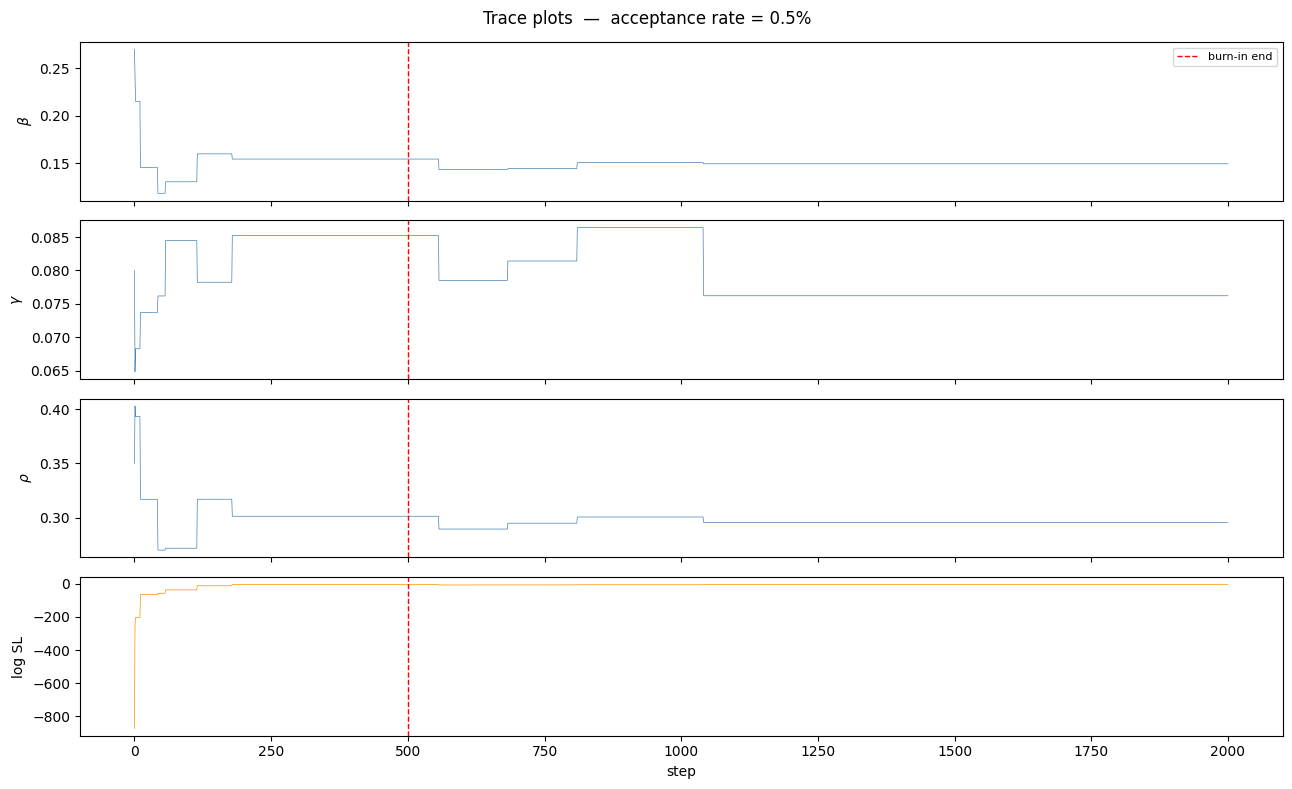

In [7]:
# ── Trace plots ───────────────────────────────────────────────────────────────
param_labels = [r"$\beta$", r"$\gamma$", r"$\rho$"]
fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
for ax, j, name in zip(axes[:3], range(3), param_labels):
    ax.plot(chain[:, j], lw=0.5, color="steelblue")
    ax.axvline(BURN_IN, color="red", ls="--", lw=1, label="burn-in end")
    ax.set(ylabel=name)
axes[3].plot(lls, lw=0.5, color="darkorange")
axes[3].axvline(BURN_IN, color="red", ls="--", lw=1)
axes[3].set(ylabel="log SL", xlabel="step")
axes[0].legend(fontsize=8)
plt.suptitle(f"Trace plots  —  acceptance rate = {acc_rate:.1%}")
plt.tight_layout()

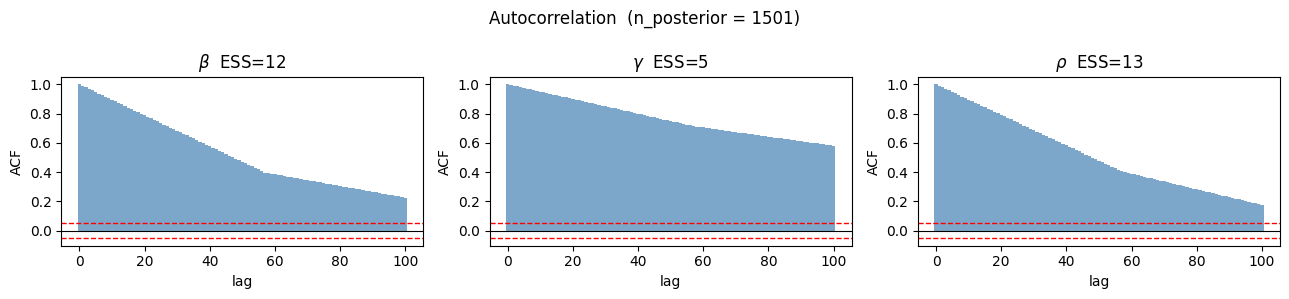

In [8]:
# ── Autocorrelation & ESS ─────────────────────────────────────────────────────
posterior = chain[BURN_IN:]   # (n_steps - burn_in, 3)

def autocorr(x, max_lag=100):
    x = x - x.mean()
    n = len(x)
    result = np.correlate(x, x, mode="full")[n-1:]
    return result[:max_lag+1] / result[0]

def ess(x):
    """Effective sample size via integrated autocorrelation time."""
    ac = autocorr(x, max_lag=min(500, len(x)//2))
    # sum until first negative lag (Geyer's initial monotone sequence)
    tau = 1 + 2 * np.sum(ac[1:][ac[1:] > 0])
    return len(x) / tau

MAX_LAG = 100
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, j, name in zip(axes, range(3), param_labels):
    ac = autocorr(posterior[:, j], MAX_LAG)
    ax.bar(np.arange(MAX_LAG+1), ac, width=1, color="steelblue", alpha=0.7)
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(1.96/np.sqrt(len(posterior)), color="red", ls="--", lw=1)
    ax.axhline(-1.96/np.sqrt(len(posterior)), color="red", ls="--", lw=1)
    e = ess(posterior[:, j])
    ax.set(title=f"{name}  ESS={e:.0f}", xlabel="lag", ylabel="ACF")
plt.suptitle(f"Autocorrelation  (n_posterior = {len(posterior)})")
plt.tight_layout()

In [9]:
# ── Thinned chain ─────────────────────────────────────────────────────────────
# Thin to reduce autocorrelation — pick lag where ACF first drops below 0.1
THIN = 1
for j in range(3):
    ac = autocorr(posterior[:, j], 200)
    below = np.where(np.abs(ac) < 0.1)[0]
    if len(below) > 0:
        THIN = max(THIN, below[0])

posterior_thin = posterior[::THIN]
print(f"Thinning interval: {THIN}")
print(f"Posterior samples after thinning: {len(posterior_thin)}")
for j, name in enumerate(["beta", "gamma", "rho"]):
    print(f"  ESS {name}: {ess(posterior_thin[:, j]):.0f}")

Thinning interval: 133
Posterior samples after thinning: 12
  ESS beta: 11
  ESS gamma: 5
  ESS rho: 9


## 6. Posterior

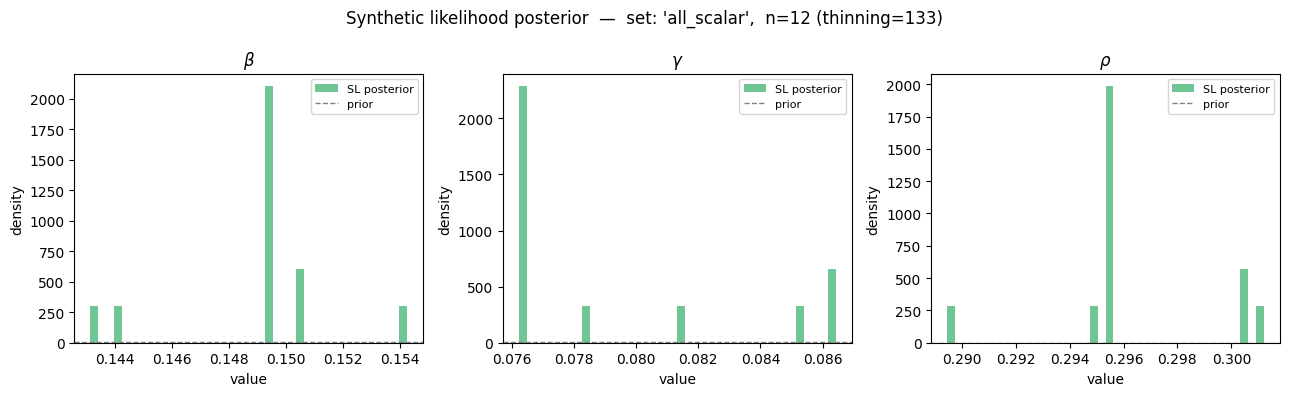

In [10]:
# ── Marginal posteriors ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, j, name in zip(axes, range(3), param_labels):
    ax.hist(posterior_thin[:, j], bins=40, density=True,
            color="mediumseagreen", alpha=0.75, label="SL posterior")
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="grey",
               ls="--", lw=1, label="prior")
    ax.set(title=name, xlabel="value", ylabel="density")
    ax.legend(fontsize=8)
plt.suptitle(f"Synthetic likelihood posterior  —  set: '{ACTIVE_SET}',  "
             f"n={len(posterior_thin)} (thinning={THIN})")
plt.tight_layout()

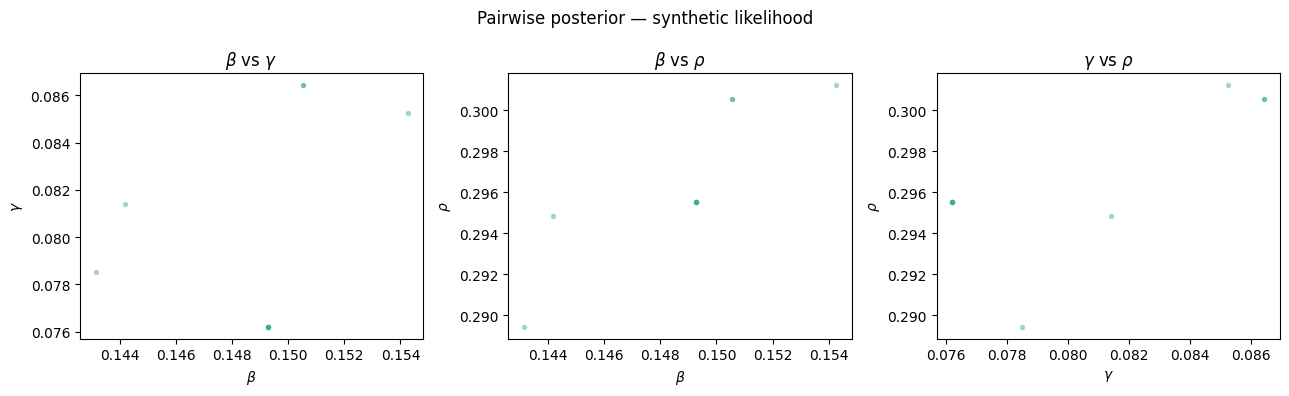

In [11]:
# ── Pairwise scatter ──────────────────────────────────────────────────────────
pairs       = [(0, 1), (0, 2), (1, 2)]
pair_labels = [(r"$\beta$", r"$\gamma$"), (r"$\beta$", r"$\rho$"), (r"$\gamma$", r"$\rho$")]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (i, j), (xi, xj) in zip(axes, pairs, pair_labels):
    ax.scatter(posterior_thin[:, i], posterior_thin[:, j],
               s=8, alpha=0.4, color="mediumseagreen", rasterized=True)
    ax.set(xlabel=xi, ylabel=xj, title=f"{xi} vs {xj}")
plt.suptitle("Pairwise posterior — synthetic likelihood")
plt.tight_layout()

## 7. Sensitivity to $N_\text{sim}$

The SL estimator has Monte Carlo noise that decreases with $N_\text{sim}$.  
Too small → noisy likelihood → inflated posterior.  Too large → slow.

A quick check: run short chains at different $N_\text{sim}$ and compare posterior widths.

Done in 33.1s  |  acceptance rate = 3.8%
N_sim= 20  accept=3.8%
Done in 161.3s  |  acceptance rate = 3.2%
N_sim= 50  accept=3.2%
Done in 144.6s  |  acceptance rate = 2.8%
N_sim=100  accept=2.8%


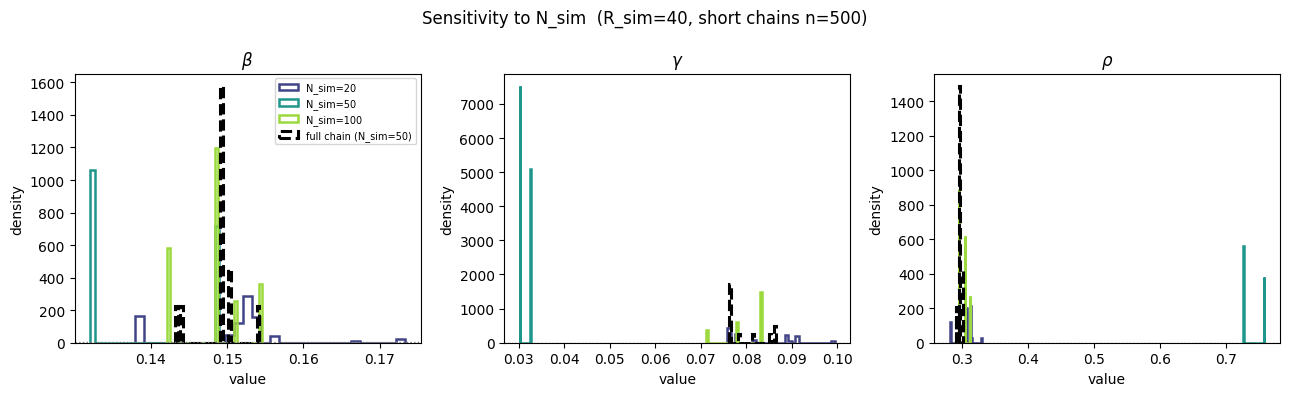

In [12]:
N_SIM_VALUES  = [20, 50, 100]   # values to compare
N_STEPS_QUICK = 500             # short chains just for comparison

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(N_SIM_VALUES)))

for color, n in zip(colors, N_SIM_VALUES):
    ch, _, ar = run_mcmc(
        N_STEPS_QUICK, THETA_INIT, s_obs, n, R_SIM,
        STEP_SIZE, seed=42, cov_estimator=COV_EST, verbose=False,
    )
    post = ch[BURN_IN // (N_STEPS // N_STEPS_QUICK):]
    print(f"N_sim={n:>3}  accept={ar:.1%}")
    for ax, j, name in zip(axes, range(3), param_labels):
        ax.hist(post[:, j], bins=30, density=True, histtype="step",
                linewidth=1.8, color=color, label=f"N_sim={n}")

for ax, j, name in zip(axes, range(3), param_labels):
    ax.hist(posterior_thin[:, j], bins=30, density=True, histtype="step",
            linewidth=2.2, color="black", ls="--", label=f"full chain (N_sim={N_SIM})")
    ax.axhline(1 / (PRIOR_HIGH[j] - PRIOR_LOW[j]), color="grey", ls=":", lw=1)
    ax.set(title=name, xlabel="value", ylabel="density")
axes[0].legend(fontsize=7)
plt.suptitle(f"Sensitivity to N_sim  (R_sim={R_SIM}, short chains n={N_STEPS_QUICK})")
plt.tight_layout()

## 8. Summary Table

In [13]:
rows = []
for j, pname in enumerate(["beta", "gamma", "rho"]):
    s = posterior_thin[:, j]
    rows.append({
        "param": pname,
        "mean":  s.mean(),
        "std":   s.std(),
        "q05":   np.quantile(s, 0.05),
        "q50":   np.quantile(s, 0.50),
        "q95":   np.quantile(s, 0.95),
        "ESS":   ess(s),
    })
display(pd.DataFrame(rows).set_index("param").round(4))

,mean,std,q05,q50,q95,ESS
param,,,,,,
beta,0.1490,0.0027,0.1437,0.1493,0.1522,10.5313
gamma,0.0793,0.0042,0.0762,0.0762,0.0864,4.6071
rho,0.2963,0.0031,0.2924,0.2955,0.3009,8.5924
